# Persona 2 — Indice y Spread

Indice leave-one-out, estimacion de beta, spreads y pruebas de estacionariedad.

## 1. Descarga de datos con cache en CSV

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path

tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS']
start = '2008-01-01'
end = '2025-01-01'

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
csv_path = data_dir / 'precios_cierre.csv'

if csv_path.exists():
    print('Leyendo CSV cacheado...')
    data = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    print('Descargando datos desde yfinance...')
    raw = yf.download(tickers, start=start, end=end, auto_adjust=False)
    data = raw['Close']
    data.to_csv(csv_path)
    print(f'Datos guardados en {csv_path}')

print(f'Shape (crudo): {data.shape}')

# truncamos al rango comun donde todos los tickers tienen datos
data = data.dropna()
print(f'Shape (rango comun): {data.shape}')
print(f'Rango de fechas: {data.index[0].date()} a {data.index[-1].date()}')
data.head()

Leyendo CSV cacheado...
Shape (crudo): (4279, 8)
Shape (rango comun): (1739, 8)
Rango de fechas: 2018-02-02 a 2024-12-31


,BMA,CEPU,GGAL,LOMA,PAM,SUPV,TGS,YPF
Date,,,,,,,,
2018-02-02,100.830002,17.700001,63.650002,22.990000,64.849998,30.389999,21.770000,23.190001
2018-02-05,96.690002,17.500000,61.320000,21.770000,62.259998,29.100000,21.219999,22.549999
2018-02-06,101.220001,17.410000,64.389999,22.500000,65.489998,30.170000,22.900000,22.950001
2018-02-07,99.330002,17.110001,63.029999,21.889999,63.799999,29.930000,22.500000,22.070000
2018-02-08,95.459999,16.400000,60.290001,21.160000,61.139999,28.260000,20.920000,21.430000


## 2. Retornos diarios

Calculamos retornos diarios para cada accion:  $r_t = \frac{P_t}{P_{t-1}} - 1$

In [2]:
returns = data.pct_change().dropna()
print(f'Retornos - Shape: {returns.shape}')
print(f'Rango de fechas: {returns.index[0].date()} a {returns.index[-1].date()}')
returns.head()

Retornos - Shape: (1738, 8)
Rango de fechas: 2018-02-05 a 2024-12-31


,BMA,CEPU,GGAL,LOMA,PAM,SUPV,TGS,YPF
Date,,,,,,,,
2018-02-05,-0.041059,-0.011299,-0.036606,-0.053067,-0.039938,-0.042448,-0.025264,-0.027598
2018-02-06,0.046851,-0.005143,0.050065,0.033532,0.051879,0.036770,0.079171,0.017738
2018-02-07,-0.018672,-0.017231,-0.021121,-0.027111,-0.025805,-0.007955,-0.017467,-0.038344
2018-02-08,-0.038961,-0.041496,-0.043471,-0.033349,-0.041693,-0.055797,-0.070222,-0.028999
2018-02-09,-0.006495,0.057927,-0.022226,0.017486,-0.035002,0.015924,-0.023901,-0.014466


## 3. Indices sinteticos leave-one-out

Para cada accion construimos un indice con el promedio de retornos de **las demas** acciones y lo acumulamos:

$$I_{-a, t} = I_{-a, t-1} \cdot (1 + \bar{r}_{-a, t})$$

con $I_{-a, 0} = 1$

In [3]:
indices_loo = {}

for ticker in tickers:
    otros = [t for t in tickers if t != ticker]
    ret_promedio = returns[otros].mean(axis=1)
    indice = (1 + ret_promedio).cumprod()
    indice.iloc[0] = 1.0
    indices_loo[ticker] = indice

indices_loo = pd.DataFrame(indices_loo, index=returns.index)
print(f'Indices LOO - Shape: {indices_loo.shape}')
indices_loo.head()

Indices LOO - Shape: (1738, 8)


,YPF,GGAL,BMA,SUPV,LOMA,CEPU,PAM,TGS
Date,,,,,,,,
2018-02-05,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2018-02-06,1.004712,1.001594,1.002697,1.004295,1.006319,1.005431,1.001837,0.995905
2018-02-07,0.985284,0.979761,0.980490,0.980514,0.985244,0.982956,0.980670,0.973676
2018-02-08,0.939540,0.936299,0.936364,0.938746,0.940115,0.939075,0.936918,0.934205
2018-02-09,0.940038,0.937834,0.935794,0.935168,0.936322,0.929862,0.940164,0.935960


### Verificacion: accion vs su indice leave-one-out

Graficamos cada accion normalizada (base 100) contra su indice LOO.

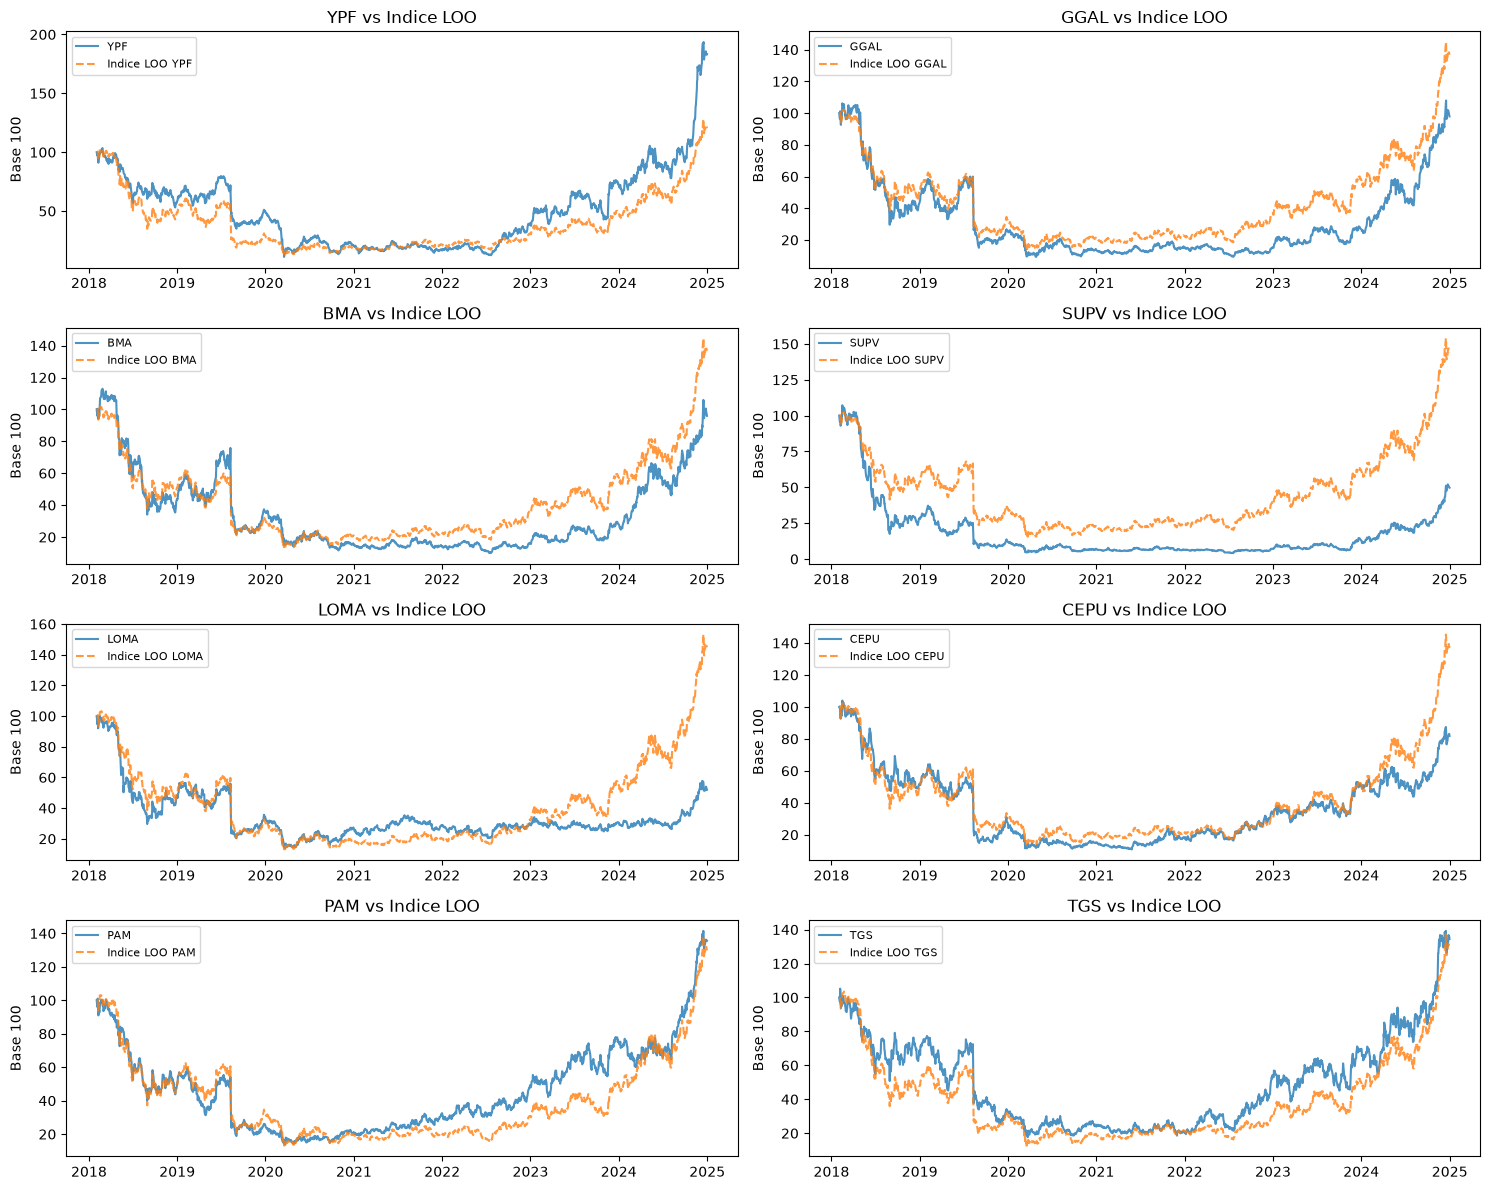

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    precio_norm = data[ticker] / data[ticker].iloc[0] * 100
    indice_norm = indices_loo[ticker] / indices_loo[ticker].iloc[0] * 100
    ax.plot(precio_norm.index, precio_norm, label=ticker, alpha=0.8)
    ax.plot(indice_norm.index, indice_norm, label=f'Indice LOO {ticker}', alpha=0.8, linestyle='--')
    ax.set_title(f'{ticker} vs Indice LOO')
    ax.legend(fontsize=8)
    ax.set_ylabel('Base 100')

plt.tight_layout()
plt.show()

### Comparacion: todos los indices LOO juntos

Como cada indice excluye solo 1 de 8 acciones, deberian ser practicamente identicos.

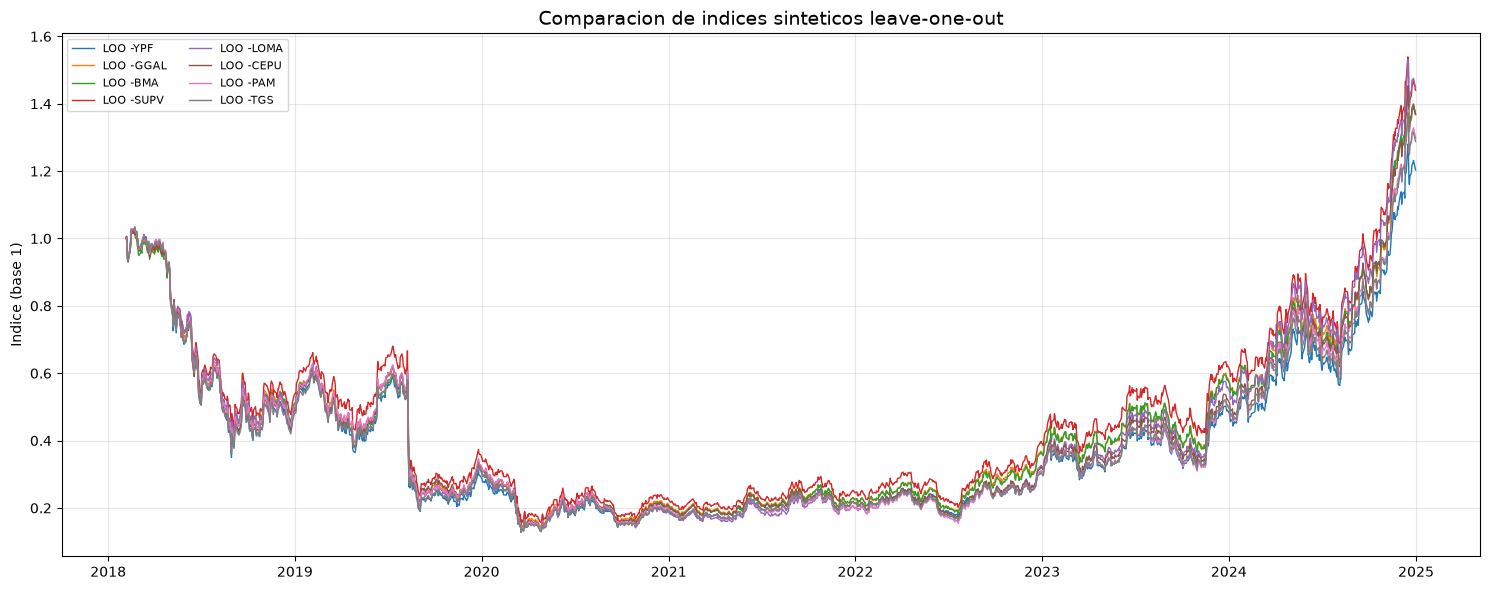

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))

for ticker in tickers:
    ax.plot(indices_loo.index, indices_loo[ticker], label=f'LOO -{ticker}', linewidth=1)

ax.set_title('Comparacion de indices sinteticos leave-one-out', fontsize=14)
ax.set_ylabel('Indice (base 1)')
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Estimacion de β rolling

Regresion OLS rodante de log(Precio) contra log(Indice LOO) con ventana de 252 ruedas.

$$\beta_t = \frac{\text{Cov}(\log P, \log I)}{\text{Var}(\log I)}$$

$$\alpha_t = \overline{\log P} - \beta_t \cdot \overline{\log I}$$

In [6]:
ventana = 252  # ~1 anio de ruedas

betas = {}
alphas = {}

for ticker in tickers:
    log_p = np.log(data[ticker])
    log_i = np.log(indices_loo[ticker])

    cov = log_p.rolling(ventana).cov(log_i)
    var = log_i.rolling(ventana).var()
    beta = cov / var
    alpha = log_p.rolling(ventana).mean() - beta * log_i.rolling(ventana).mean()

    betas[ticker] = beta
    alphas[ticker] = alpha

betas = pd.DataFrame(betas, index=returns.index)
alphas = pd.DataFrame(alphas, index=returns.index)

print(f"Betas rolling - Shape: {betas.shape}")
print(betas.head())

Betas rolling - Shape: (1738, 8)
            YPF  GGAL  BMA  SUPV  LOMA  CEPU  PAM  TGS
Date                                                  
2018-02-05  NaN   NaN  NaN   NaN   NaN   NaN  NaN  NaN
2018-02-06  NaN   NaN  NaN   NaN   NaN   NaN  NaN  NaN
2018-02-07  NaN   NaN  NaN   NaN   NaN   NaN  NaN  NaN
2018-02-08  NaN   NaN  NaN   NaN   NaN   NaN  NaN  NaN
2018-02-09  NaN   NaN  NaN   NaN   NaN   NaN  NaN  NaN


### Evolucion de β en el tiempo

Graficamos como cambia la sensibilidad de cada accion al mercado.

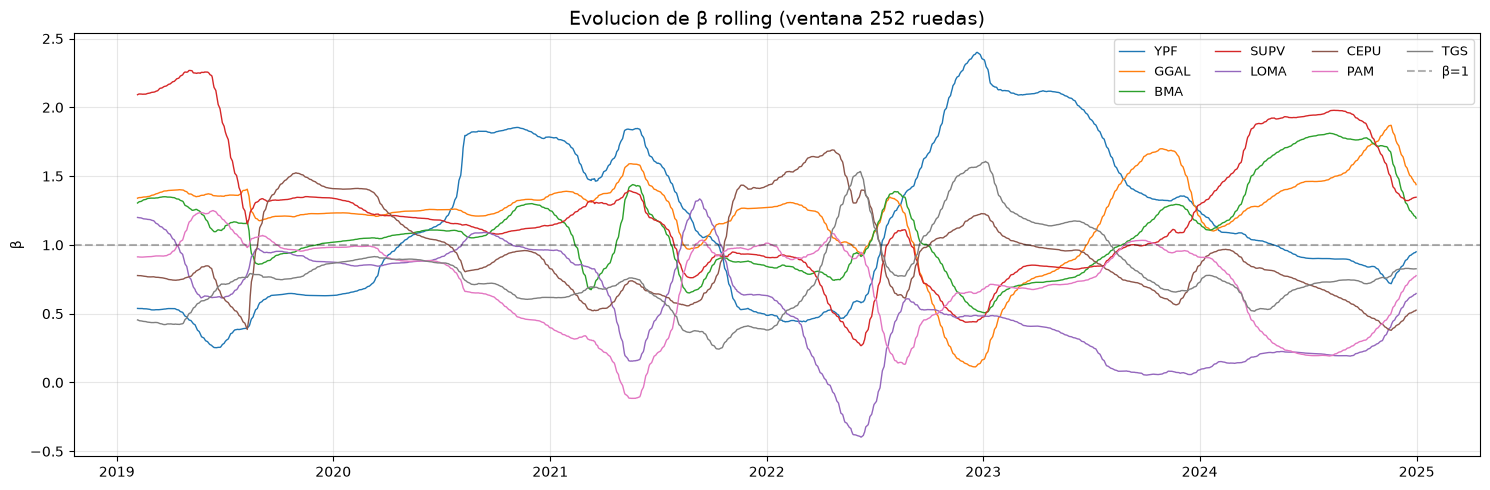

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))

for ticker in tickers:
    ax.plot(betas.index, betas[ticker], label=ticker, linewidth=1)

ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.3, label="β=1")
ax.set_title("Evolucion de β rolling (ventana 252 ruedas)", fontsize=14)
ax.set_ylabel("β")
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Spreads

Calculamos la divergencia relativa:

$$S_t = \log(P_t) - \alpha_t - \beta_t \cdot \log(I_{-ticker, t})$$

In [8]:
spreads = {}

for ticker in tickers:
    log_p = np.log(data[ticker])
    log_i = np.log(indices_loo[ticker])
    spread = log_p - alphas[ticker] - betas[ticker] * log_i
    spreads[ticker] = spread

spreads = pd.DataFrame(spreads, index=returns.index)

# descartamos las primeras filas donde no hay beta (ventana insuficiente)
spreads = spreads.dropna()

print(f"Spreads - Shape: {spreads.shape}")
spreads.head()

Spreads - Shape: (1487, 8)


,YPF,GGAL,BMA,SUPV,LOMA,CEPU,PAM,TGS
Date,,,,,,,,
2019-02-05,-0.022439,0.032225,-0.029081,-0.168194,0.053968,-0.034667,-0.104741,0.030305
2019-02-06,-0.034281,0.018142,-0.032786,-0.161475,0.051262,-0.016944,-0.074001,0.018595
2019-02-07,-0.055299,0.048156,-0.003299,-0.114370,0.040133,-0.047086,-0.070109,-0.007616
2019-02-08,-0.058691,0.056515,-0.009273,-0.122224,0.024298,-0.057063,-0.054374,0.005627
2019-02-11,-0.077725,0.049885,-0.022589,-0.144835,0.003278,-0.043214,-0.022155,0.032234


### Visualizacion de spreads

Cada spread representa el movimiento particular de la accion no explicado por el panel.

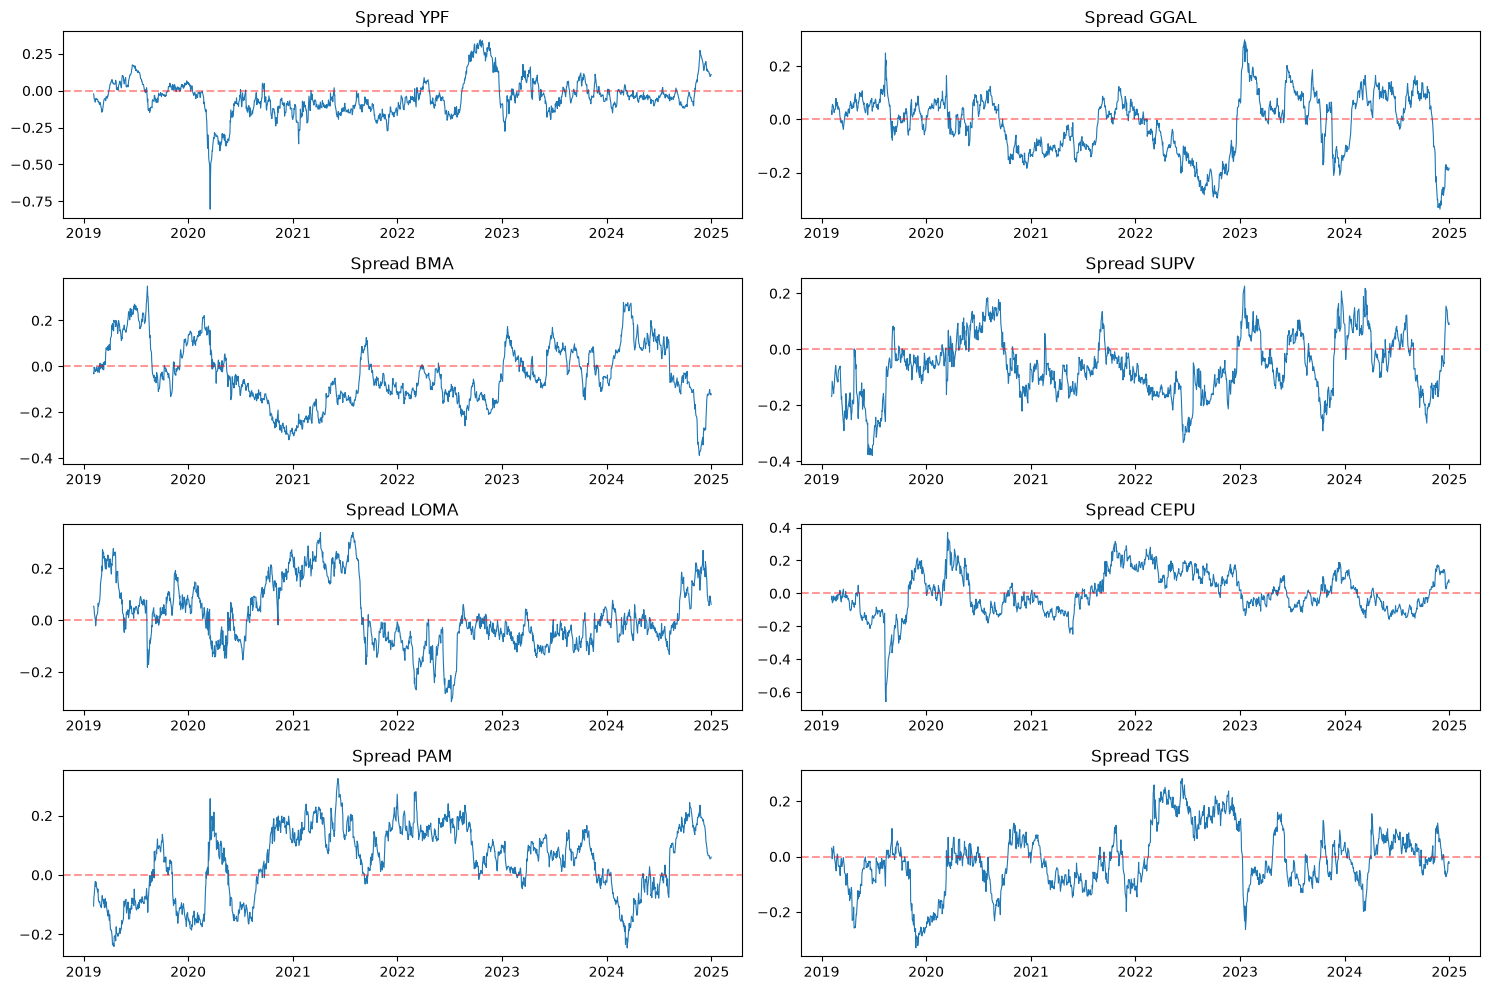

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    ax.plot(spreads.index, spreads[ticker], linewidth=0.8)
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.4)
    ax.set_title(f"Spread {ticker}")

plt.tight_layout()
plt.show()

## 6. Tests de estacionariedad

Aplicamos dos tests sobre cada spread:

- **ADF** (Augmented Dickey-Fuller): H0 = la serie tiene raiz unitaria (no estacionaria)
- **KPSS**: H0 = la serie es estacionaria

Combinando ambos podemos clasificar cada spread.

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

alpha = 0.05

resultados = []

for ticker in tickers:
    s = spreads[ticker].dropna()

    adf_stat, adf_pval, _, _, adf_cv, _ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")

    adf_rechaza = adf_pval < alpha
    kpss_no_rechaza = kpss_pval >= alpha

    if adf_rechaza and kpss_no_rechaza:
        conc = "Estacionario"
    elif not adf_rechaza and not kpss_no_rechaza:
        conc = "No estacionario"
    elif adf_rechaza and not kpss_no_rechaza:
        conc = "Ambos rechazan - dudoso"
    else:
        conc = "Ninguno rechaza - dudoso"

    resultados.append({
        "Ticker": ticker,
        "ADF stat": f"{adf_stat:.4f}",
        "ADF p-val": f"{adf_pval:.4f}",
        "KPSS stat": f"{kpss_stat:.4f}",
        "KPSS p-val": f"{kpss_pval:.4f}",
        "Conclusion": conc
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

/tmp/nix-shell-182777-89586139/ipykernel_183363/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")
/tmp/nix-shell-182777-89586139/ipykernel_183363/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")
/tmp/nix-shell-182777-89586139/ipykernel_183363/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")
/tmp/nix-shell-182777-89586139/ipykernel_183363/1884720380.py:11: Interpolat

,Ticker,ADF stat,ADF p-val,KPSS stat,KPSS p-val,Conclusion
0,YPF,-4.1351,0.0008,0.6347,0.0195,Ambos rechazan - dudoso
1,GGAL,-4.0518,0.0012,0.2966,0.1000,Estacionario
2,BMA,-3.0639,0.0293,0.5486,0.0307,Ambos rechazan - dudoso
3,SUPV,-4.5131,0.0002,0.3512,0.0982,Estacionario
4,LOMA,-3.4722,0.0087,1.0010,0.0100,Ambos rechazan - dudoso
5,CEPU,-4.3461,0.0004,0.5195,0.0373,Ambos rechazan - dudoso
6,PAM,-3.0645,0.0293,0.9597,0.0100,Ambos rechazan - dudoso
7,TGS,-3.6349,0.0051,0.9771,0.0100,Ambos rechazan - dudoso
